In [1]:
import pandas as pd
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Encoding and scaling**

In [2]:
from preprocessor import preprocess_tender_data

data = pd.read_csv('/Users/polina/b2b_reccomendation_systems/preprocessed_full.csv')

In [3]:
data.columns

Index(['Unnamed: 0', 'Уровень', 'Заказчик', 'ИНН заказчика',
       'Стоимость(руб.) Заказчик', 'Реестровый номер публикации',
       'Сфера деятельности', 'Регион поставки', 'Город поставки',
       'Дата публикации',
       'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ',
       'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ',
       'Дата окончания проведения торгов', 'Поставщик', 'ИНН поставщика',
       'Победитель', 'Статус допуска', 'Снижение на торгах,%',
       'Форма публикации', 'Тип торгов', 'Обеспечение заявки (руб.)',
       'Обеспечение заявки, %', 'Обеспечение контракта (руб.)',
       'Обеспечение контракта, %', 'РНП ранее', 'Выручка', 'Сводный риск',
       'log_profit', 'log_cost', 'year', 'month', 'win_rate', 'region_wins',
       'region_win_rate', 'customer_wins', 'customer_win_rate', 'sphere_wins',
       'sphere_win_rate', 'total_wins', 'avg_price_drop',
  

In [4]:
data = data.drop(columns = ['Unnamed: 0'])

In [5]:
data.dtypes

Уровень                                                                                                                  int64
Заказчик                                                                                                                object
ИНН заказчика                                                                                                            int64
Стоимость(руб.) Заказчик                                                                                               float64
Реестровый номер публикации                                                                                              int64
Сфера деятельности                                                                                                      object
Регион поставки                                                                                                         object
Город поставки                                                                                                 

In [6]:
pd.options.display.float_format = '{:,.2f}'.format 

data['Обеспечение заявки (руб.)'].describe()

count       492,021.00
mean         28,037.13
std       1,832,071.73
min               0.00
25%               0.00
50%               0.00
75%               0.00
max     726,586,733.49
Name: Обеспечение заявки (руб.), dtype: float64

In [7]:
print(data[data['Обеспечение заявки (руб.)'] == 0].shape)
print(data[data['Обеспечение заявки, %'] == 0].shape)
print(data[data['Обеспечение контракта (руб.)'] == 0].shape)
print(data[data['Обеспечение контракта, %'] == 0].shape)

(473505, 51)
(473598, 51)
(458708, 51)
(458708, 51)


In [8]:
#data.to_csv('preprocessed_full.csv')

In [8]:
data[data['Выручка'] <= 0]['Выручка'].groupby(data['ИНН поставщика']).count()

Series([], Name: Выручка, dtype: int64)

In [9]:
data.shape

(492021, 51)

In [10]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler

num = [
    "avg_price_drop",
    "log_cost",
    "log_profit",
    "Снижение на торгах,%",
    'win_rate',  'region_win_rate', 
    'customer_win_rate', 'sphere_win_rate',
    "days_between",
    "region_wins",
    "customer_wins",
    "sphere_wins",
    "total_wins",
    "competitors_per_tender",
    "avg_competitors_in_region",
    "avg_competitors_in_sphere",
    "avg_competitors_in_customer",
    "Обеспечение заявки (руб.)",
    "Обеспечение заявки, %",
    "Обеспечение контракта (руб.)",
    "Обеспечение контракта, %"
]

cat = [
    "Сфера деятельности",
    "Регион поставки",
    "Город поставки",
    "Тип торгов",
    "Уровень",
    "year",
    "month",
    "Сводный риск"
]

binary_features = [
    "РНП ранее", 
    "is_january", 
    "publication_peak_9_11", 
    "app_end_noon_12", 
    "app_start_night_12",
    "trade_end_night_12",
    "is_2019",
    "is_jan_to_april",
    "Статус допуска"
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat),
        ('pass', 'passthrough', binary_features)
    ],
    remainder='drop'
    )

train = data[data['year'].isin(range(2015, 2021))]
test = data[data['year'].isin(range(2021, 2026))]
X_train = train[num + cat + binary_features]
y_train = train["Победитель"]
X_test = test[num + cat + binary_features]
y_test = test["Победитель"]

In [11]:
print(X_test.shape)
print(X_train.shape)

(51991, 38)
(440030, 38)


In [12]:
X_train = X_train.sample(n=100000, random_state=42)
y_train = y_train.sample(n=100000, random_state=42)

____________________________________________________________________________________________________________________

**Модели**

In [13]:
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{name} Metrics:")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall:", round(recall_score(y_true, y_pred), 4))
    print("F1-Score:", round(f1_score(y_true, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_proba), 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    plt.figure(figsize=(10, 8))
    conf_matrix = confusion_matrix(y_true, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Winner', 'Winner'],
                yticklabels=['Not Winner', 'Winner'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def draw_roc_curve(y_test, y_proba, name):
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkcyan', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC curve')
    plt.legend(loc='lower right')
    plt.show()

Важный вопрос - какая метрика нам все-таки важнее, precision или recall? Как будто для задачи победителя тендера, нам интереснее recall, поскольку мы хотим не пропустить потенциальных победителей, но это пока мысли (то есть мы можем пожертвовать precision - лучше попадет несколько ложных, но среди всех предсказанных с большей вероятностью будет потенциальный победитель) - так как пока неясно, подбираю по f1, то есть по сумме precision и recall

1. KNN (k nearest neighbors)

In [14]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

In [15]:
print(np.sum(y_train))
print(y_train.shape[0])
print(np.sum(y_train)/y_train.shape[0])

199772
440030
0.4539963184328341


In [16]:
print(np.sum(y_test))
print(y_test.shape[0])
print(np.sum(y_test)/y_test.shape[0])

36502
51991
0.7020830528360678


Применим андерсемплинг мажорного класса к обучающей выборке (которая включает в себя и валидацию), чтобы получить адекватные результаты - в тесте явно превалируют победители

In [17]:
numeric = data.select_dtypes(include=np.number)
numeric = numeric.drop(columns=['ИНН заказчика', 'Стоимость(руб.) Заказчик', 'Реестровый номер публикации', 'ИНН поставщика', 'Победитель', 'Выручка', 'Сводный риск'])

In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample 
from collections import Counter
import math

def proportional_cluster_undersampling(X, y, majority_label, numerical_cols, minority_label, 
    n_clusters=10,sampling_factor=1.1, random_state=42):
    
    X_maj = X[y == majority_label]
    y_maj = y[y == majority_label]
    X_min = X[y == minority_label]
    y_min = y[y == minority_label]
    
    n_minority = len(X_min)
    n_majority_original = len(X_maj)
         
    print(f"Исходный размер: Маж.={n_majority_original}, Мин.={n_minority}")

    scaler = StandardScaler()
    X_maj_numeric = X_maj[numerical_cols]
    X_maj_scaled = scaler.fit_transform(X_maj_numeric)
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_maj_numeric)
    
    cluster_counts = Counter(cluster_labels)
    cluster_proportions = {cls: count / n_majority_original for cls, count in cluster_counts.items()}
    print("Пропорции кластеров в исходном мажоритарном классе:")
    for cls, prop in sorted(cluster_proportions.items()):
         print(f"  Кластер {cls}: {prop:.3f} (Кол-во: {cluster_counts[cls]})")


    n_majority_target = math.ceil(n_minority * sampling_factor) 
    if n_majority_target > n_majority_original:
         print(f"Предупреждение: Целевой размер маж. класса ({n_majority_target}) больше исходного ({n_majority_original}). Используется исходный размер.")
         n_majority_target = n_majority_original
         
    print(f"Целевой размер мажоритарного класса после сэмплинга: {n_majority_target}")

    target_samples_per_cluster = {}
    total_samples_calculated = 0

    for cls, proportion in cluster_proportions.items():
         n_samples = round(n_majority_target * proportion) 
         n_samples = min(n_samples, cluster_counts[cls]) 
         target_samples_per_cluster[cls] = n_samples
         total_samples_calculated += n_samples
         

    diff = n_majority_target - total_samples_calculated
    if diff != 0:
        print(f"Корректировка размера выборки из-за округления: {diff}")
        largest_cluster = max(cluster_counts, key=cluster_counts.get)
        target_samples_per_cluster[largest_cluster] += diff
        target_samples_per_cluster[largest_cluster] = max(0, target_samples_per_cluster[largest_cluster])
        target_samples_per_cluster[largest_cluster] = min(cluster_counts[largest_cluster], target_samples_per_cluster[largest_cluster])
        final_total_samples = sum(target_samples_per_cluster.values())
        if final_total_samples != n_majority_target:
             print(f"Предупреждение: Не удалось точно достичь целевого размера {n_majority_target} из-за округления и размеров кластеров. Итоговый размер: {final_total_samples}")


    sampled_indices = []
    majority_indices = X_maj.index 

    for cls, n_to_sample in target_samples_per_cluster.items():
        if n_to_sample == 0:
            continue
            
        indices_in_cluster = majority_indices[cluster_labels == cls]
        n_to_sample = min(n_to_sample, len(indices_in_cluster)) 
        
        if n_to_sample > 0:
             sampled_cluster_indices = resample(
                 indices_in_cluster, 
                 n_samples=n_to_sample, 
                 replace=False,
                 random_state=random_state
             )
             sampled_indices.extend(sampled_cluster_indices)
             
 
    X_maj_sampled = X_maj.loc[sampled_indices]
    y_maj_sampled = y_maj.loc[sampled_indices]
    
    X_resampled = pd.concat([X_maj_sampled, X_min], ignore_index=True)
    y_resampled = pd.concat([y_maj_sampled, y_min], ignore_index=True)
    
    np.random.seed(random_state) 
    shuffled_indices = np.random.permutation(len(X_resampled))
    X_resampled = X_resampled.iloc[shuffled_indices].reset_index(drop=True)
    y_resampled = y_resampled.iloc[shuffled_indices].reset_index(drop=True)
    
    print(f"Итоговый размер: {len(X_resampled)}")
    print("Распределение классов в итоговой выборке:")
    print(y_resampled.value_counts())
    
    return X_resampled, y_resampled


majority_class_label = 0 
minority_class_label = 1 

X_new_train = preprocessor.fit_transform(X_train)

X_train_resampled, y_train_resampled = proportional_cluster_undersampling(
    X=X_train, y=y_train, 
    majority_label=majority_class_label, minority_label=minority_class_label, 
    n_clusters=5, sampling_factor=1.1, random_state=42, numerical_cols=numeric.columns.tolist()    
)

Исходный размер: Маж.=240258, Мин.=199772
Пропорции кластеров в исходном мажоритарном классе:
  Кластер 0: 1.000 (Кол-во: 240176)
  Кластер 1: 0.000 (Кол-во: 1)
  Кластер 2: 0.000 (Кол-во: 34)
  Кластер 3: 0.000 (Кол-во: 7)
  Кластер 4: 0.000 (Кол-во: 40)
Целевой размер мажоритарного класса после сэмплинга: 219750
Итоговый размер: 419522
Распределение классов в итоговой выборке:
Победитель
0    219750
1    199772
Name: count, dtype: int64


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify=y_train_resampled)

param_grid = {
    'classifier__n_neighbors': [161],
    'classifier__weights': ['distance'],
    'classifier__p': [1], 
    'classifier__metric': ['minkowski']
}

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=2,
    scoring='f1',
    verbose=2
)
grid_search.fit(X_val, y_val)

Fitting 2 folds for each of 1 candidates, totalling 2 fits
[CV] END classifier__metric=minkowski, classifier__n_neighbors=161, classifier__p=1, classifier__weights=distance; total time=  23.6s
[CV] END classifier__metric=minkowski, classifier__n_neighbors=161, classifier__p=1, classifier__weights=distance; total time=  22.7s


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         ['avg_price_drop',
                                                                          'log_cost',
                                                                          'log_profit',
                                                                          'Снижение '
                                                                          'на '
                                                                          'торгах,%',
                                                                          'win_rate',
                                                                          'region_win_rate',
                                                                          'customer_win_rate',
                                                                          'sphere_win_rate',
                                                                          'days_between',
                                                                          'region_wins',
                                                                          'customer_wins',
                                                                          'sphere_wins',
                                                                          'total_wins',
                                                                          'competitors_per_tender',
                                                                          'avg_...
                                                                          'ранее',
                                                                          'is_january',
                                                                          'publication_peak_9_11',
                                                                          'app_end_noon_12',
                                                                          'app_start_night_12',
                                                                          'trade_end_night_12',
                                                                          'is_2019',
                                                                          'is_jan_to_april',
                                                                          'Статус '
                                                                          'допуска'])])),
                                       ('classifier', KNeighborsClassifier())]),
             param_grid={'classifier__metric': ['minkowski'],
                         'classifier__n_neighbors': [161], 'classifier__p': [1],
                         'classifier__weights': ['distance']},
             scoring='f1', verbose=2)

In [40]:
print("\nBest parameters:", grid_search.best_params_)
print("Best f1:", round(grid_search.best_score_, 4))


Best parameters: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 161, 'classifier__p': 1, 'classifier__weights': 'distance'}
Best f1: 0.8853



Best parameters: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 161, 'classifier__p': 1, 'classifier__weights': 'distance'}
Best f1: 0.8853

Best KNN Model Metrics:
Accuracy: 0.788
Precision: 0.8766
Recall: 0.8124
F1-Score: 0.8433
ROC-AUC: 0.8704

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.73      0.67     15489
           1       0.88      0.81      0.84     36502

    accuracy                           0.79     51991
   macro avg       0.75      0.77      0.76     51991
weighted avg       0.80      0.79      0.79     51991

Confusion Matrix:
[[11315  4174]
 [ 6849 29653]]


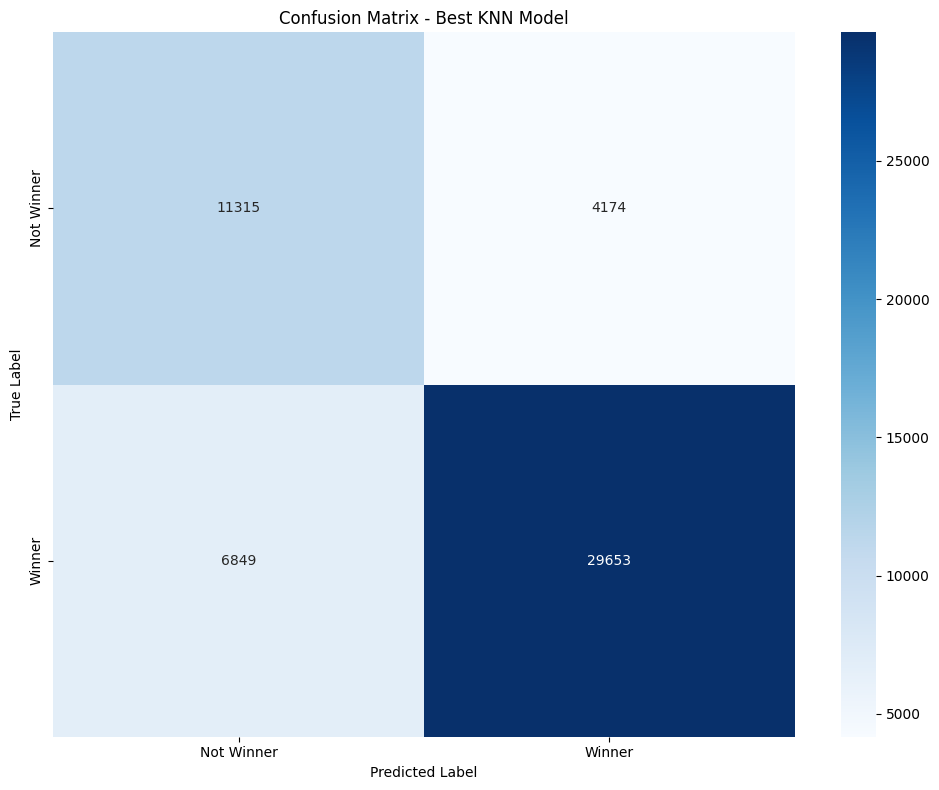

In [41]:
print("\nBest parameters:", grid_search.best_params_)
print("Best f1:", round(grid_search.best_score_, 4))
best_knn = grid_search.best_estimator_
best_knn.fit(X_train_new, y_train_new)
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]
evaluate_model("Best KNN Model", y_test, y_pred, y_proba)

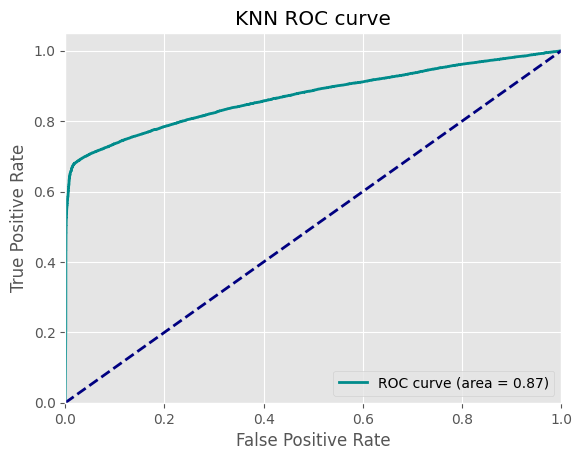

In [62]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkcyan', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC curve')
plt.legend(loc='lower right')
plt.show()

In [61]:
print("\nBest parameters:", grid_search.best_params_)
print("Best f1:", round(grid_search.best_score_, 4))


Best parameters: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 161, 'classifier__p': 1, 'classifier__weights': 'distance'}
Best f1: 0.8853


По сравнению с предыдущими моделями (без такого шкалирования и с немного иными признаками) общее качество выросло - precision немного снизился, но вот непобедителей модель начала предсказывать в разы лучше (до этого было примерно 50/50, ближе к случайному)

Глобально, чем больше соседей мы берем - тем лучше F1, иными словами растет precision за счет снижения recall

In [42]:
import joblib

best_knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=grid_search.best_params_['classifier__n_neighbors'], weights=grid_search.best_params_['classifier__weights'], metric=grid_search.best_params_['classifier__metric'], p = grid_search.best_params_['classifier__p']))
])

best_knn_pipeline.fit(X_train_new, y_train_new)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['avg_price_drop', 'log_cost',
                                                   'log_profit',
                                                   'Снижение на торгах,%',
                                                   'win_rate',
                                                   'region_win_rate',
                                                   'customer_win_rate',
                                                   'sphere_win_rate',
                                                   'days_between',
                                                   'region_wins',
                                                   'customer_wins',
                                                   'sphere_wins', 'total_wins',
                                                   'competitors_per_tender',
                                                   'avg_competitors_in_region',
                                                   'avg_comp...
                                                  ['Сфера деятельности',
                                                   'Регион поставки',
                                                   'Город поставки',
                                                   'Тип торгов', 'Уровень',
                                                   'year', 'month',
                                                   'Сводный риск']),
                                                 ('pass', 'passthrough',
                                                  ['РНП ранее', 'is_january',
                                                   'publication_peak_9_11',
                                                   'app_end_noon_12',
                                                   'app_start_night_12',
                                                   'trade_end_night_12',
                                                   'is_2019', 'is_jan_to_april',
                                                   'Статус допуска'])])),
                ('classifier',
                 KNeighborsClassifier(n_neighbors=161, p=1,
                                      weights='distance'))])

In [76]:
filename = 'models_joblib/best_knn_pipeline_model.joblib'
joblib.dump(best_knn_pipeline, filename)

['models_joblib/best_knn_pipeline_model.joblib']

In [45]:
best_knn = KNeighborsClassifier(n_neighbors=grid_search.best_params_['classifier__n_neighbors'], weights=grid_search.best_params_['classifier__weights'], metric=grid_search.best_params_['classifier__metric'], p = grid_search.best_params_['classifier__p'])

In [44]:
from sklearn.inspection import permutation_importance

X_train_new, X_val, y_train_new, y_val = train_test_split(X_train, y_train, test_size=0.05, random_state=42, stratify=y_train)

result = permutation_importance(
    best_knn_pipeline, 
    X_val, 
    y_val,
    n_repeats=2,
    random_state=42,
    scoring=['roc_auc', 'f1_weighted', 'precision_macro', 'recall_macro'],
    max_samples=0.5
)

Feature Importance Ranking for roc_auc:
customer_win_rate: 0.0169 ± 0.0001
sphere_win_rate: 0.0139 ± 0.0002
customer_wins: 0.0135 ± 0.0003
Сфера деятельности: 0.0117 ± 0.0000
sphere_wins: 0.0107 ± 0.0000
Город поставки: 0.0103 ± 0.0000
Регион поставки: 0.0102 ± 0.0001
Снижение на торгах,%: 0.0101 ± 0.0002
month: 0.0100 ± 0.0004
region_wins: 0.0099 ± 0.0000
Обеспечение контракта (руб.): 0.0099 ± 0.0003
total_wins: 0.0091 ± 0.0001
competitors_per_tender: 0.0091 ± 0.0001
log_cost: 0.0081 ± 0.0002
avg_competitors_in_sphere: 0.0081 ± 0.0001
avg_price_drop: 0.0080 ± 0.0000
avg_competitors_in_customer: 0.0079 ± 0.0000
log_profit: 0.0079 ± 0.0000
region_win_rate: 0.0077 ± 0.0000
days_between: 0.0073 ± 0.0000
Сводный риск: 0.0071 ± 0.0000
win_rate: 0.0070 ± 0.0001
avg_competitors_in_region: 0.0068 ± 0.0000
year: 0.0051 ± 0.0001
trade_end_night_12: 0.0048 ± 0.0001
Обеспечение заявки (руб.): 0.0040 ± 0.0001
Уровень: 0.0038 ± 0.0004
is_2019: 0.0036 ± 0.0001
Тип торгов: 0.0035 ± 0.0004
publication_

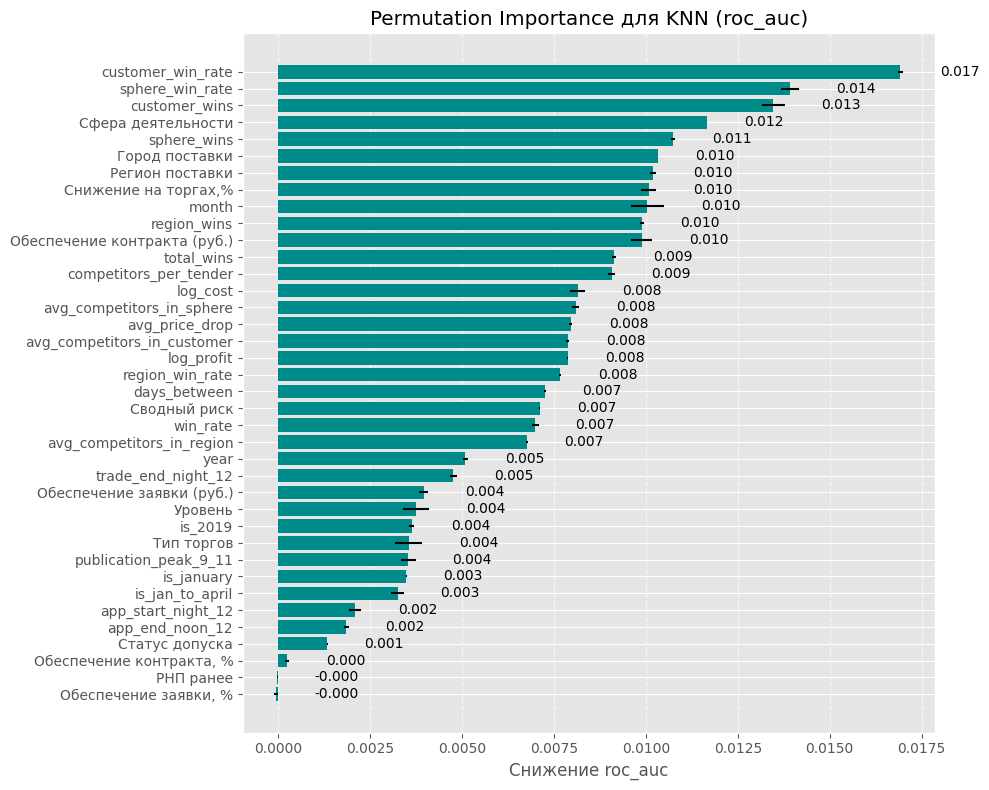

Feature Importance Ranking for f1_weighted:
customer_win_rate: 0.0418 ± 0.0004
sphere_win_rate: 0.0351 ± 0.0006
customer_wins: 0.0344 ± 0.0010
Обеспечение контракта (руб.): 0.0319 ± 0.0007
Сфера деятельности: 0.0311 ± 0.0004
sphere_wins: 0.0290 ± 0.0009
Город поставки: 0.0284 ± 0.0002
Регион поставки: 0.0280 ± 0.0001
region_wins: 0.0268 ± 0.0005
month: 0.0267 ± 0.0011
total_wins: 0.0262 ± 0.0005
Снижение на торгах,%: 0.0237 ± 0.0004
competitors_per_tender: 0.0225 ± 0.0010
avg_price_drop: 0.0207 ± 0.0003
avg_competitors_in_sphere: 0.0201 ± 0.0002
log_cost: 0.0194 ± 0.0011
log_profit: 0.0182 ± 0.0010
avg_competitors_in_customer: 0.0181 ± 0.0003
Сводный риск: 0.0177 ± 0.0011
region_win_rate: 0.0172 ± 0.0005
days_between: 0.0171 ± 0.0004
win_rate: 0.0165 ± 0.0009
avg_competitors_in_region: 0.0161 ± 0.0001
Обеспечение заявки (руб.): 0.0150 ± 0.0011
year: 0.0131 ± 0.0003
trade_end_night_12: 0.0113 ± 0.0006
publication_peak_9_11: 0.0082 ± 0.0007
Уровень: 0.0081 ± 0.0004
is_2019: 0.0079 ± 0.00

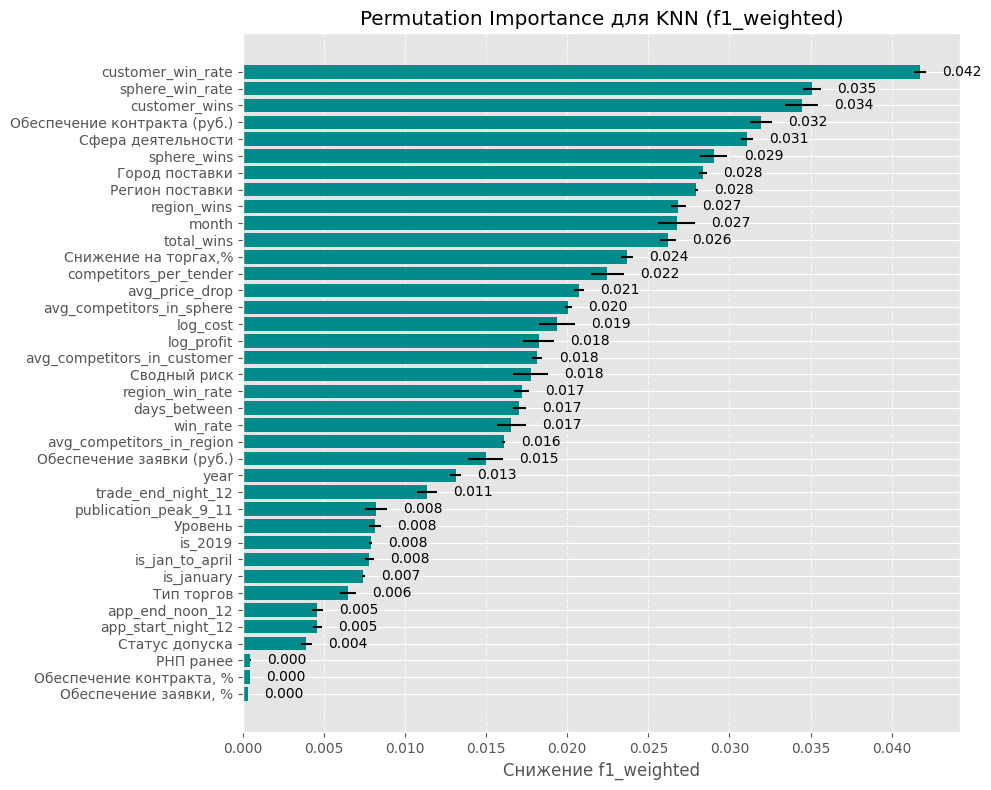

Feature Importance Ranking for precision_macro:
customer_win_rate: 0.0403 ± 0.0004
sphere_win_rate: 0.0347 ± 0.0004
customer_wins: 0.0308 ± 0.0008
Обеспечение контракта (руб.): 0.0308 ± 0.0006
Сфера деятельности: 0.0297 ± 0.0004
Город поставки: 0.0273 ± 0.0002
Регион поставки: 0.0269 ± 0.0001
sphere_wins: 0.0267 ± 0.0010
month: 0.0257 ± 0.0011
region_wins: 0.0250 ± 0.0004
total_wins: 0.0250 ± 0.0005
Снижение на торгах,%: 0.0228 ± 0.0004
competitors_per_tender: 0.0219 ± 0.0010
avg_price_drop: 0.0199 ± 0.0003
avg_competitors_in_sphere: 0.0193 ± 0.0002
log_cost: 0.0187 ± 0.0010
log_profit: 0.0177 ± 0.0010
avg_competitors_in_customer: 0.0175 ± 0.0003
Сводный риск: 0.0171 ± 0.0011
region_win_rate: 0.0168 ± 0.0004
days_between: 0.0165 ± 0.0004
win_rate: 0.0161 ± 0.0010
avg_competitors_in_region: 0.0156 ± 0.0001
Обеспечение заявки (руб.): 0.0149 ± 0.0011
year: 0.0129 ± 0.0003
trade_end_night_12: 0.0111 ± 0.0006
Уровень: 0.0082 ± 0.0003
publication_peak_9_11: 0.0081 ± 0.0007
is_2019: 0.0079 ± 

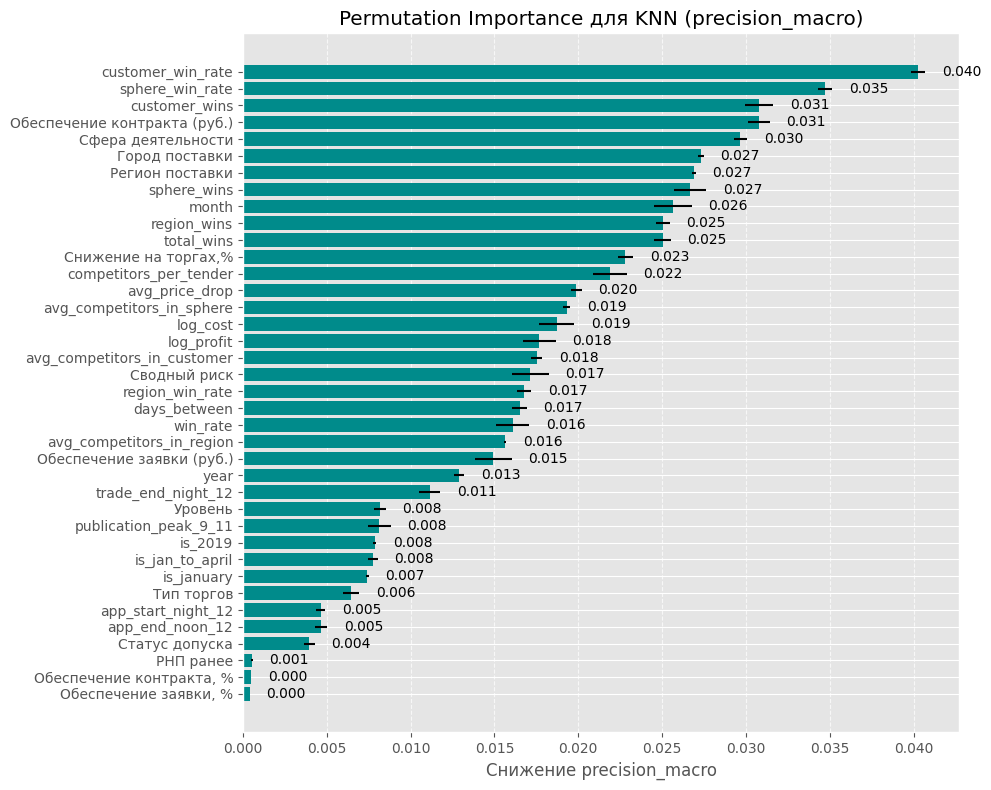

Feature Importance Ranking for recall_macro:
customer_win_rate: 0.0448 ± 0.0003
customer_wins: 0.0387 ± 0.0011
sphere_win_rate: 0.0370 ± 0.0007
Обеспечение контракта (руб.): 0.0346 ± 0.0007
Сфера деятельности: 0.0339 ± 0.0003
sphere_wins: 0.0325 ± 0.0008
Город поставки: 0.0309 ± 0.0003
Регион поставки: 0.0305 ± 0.0001
region_wins: 0.0299 ± 0.0005
month: 0.0292 ± 0.0012
total_wins: 0.0288 ± 0.0005
Снижение на торгах,%: 0.0259 ± 0.0003
competitors_per_tender: 0.0244 ± 0.0010
avg_price_drop: 0.0229 ± 0.0003
avg_competitors_in_sphere: 0.0221 ± 0.0003
log_cost: 0.0213 ± 0.0012
log_profit: 0.0200 ± 0.0009
avg_competitors_in_customer: 0.0200 ± 0.0003
Сводный риск: 0.0196 ± 0.0011
days_between: 0.0188 ± 0.0004
region_win_rate: 0.0188 ± 0.0005
win_rate: 0.0182 ± 0.0008
avg_competitors_in_region: 0.0177 ± 0.0001
Обеспечение заявки (руб.): 0.0158 ± 0.0011
year: 0.0143 ± 0.0004
trade_end_night_12: 0.0124 ± 0.0007
publication_peak_9_11: 0.0089 ± 0.0007
Уровень: 0.0086 ± 0.0004
is_2019: 0.0085 ± 0.0

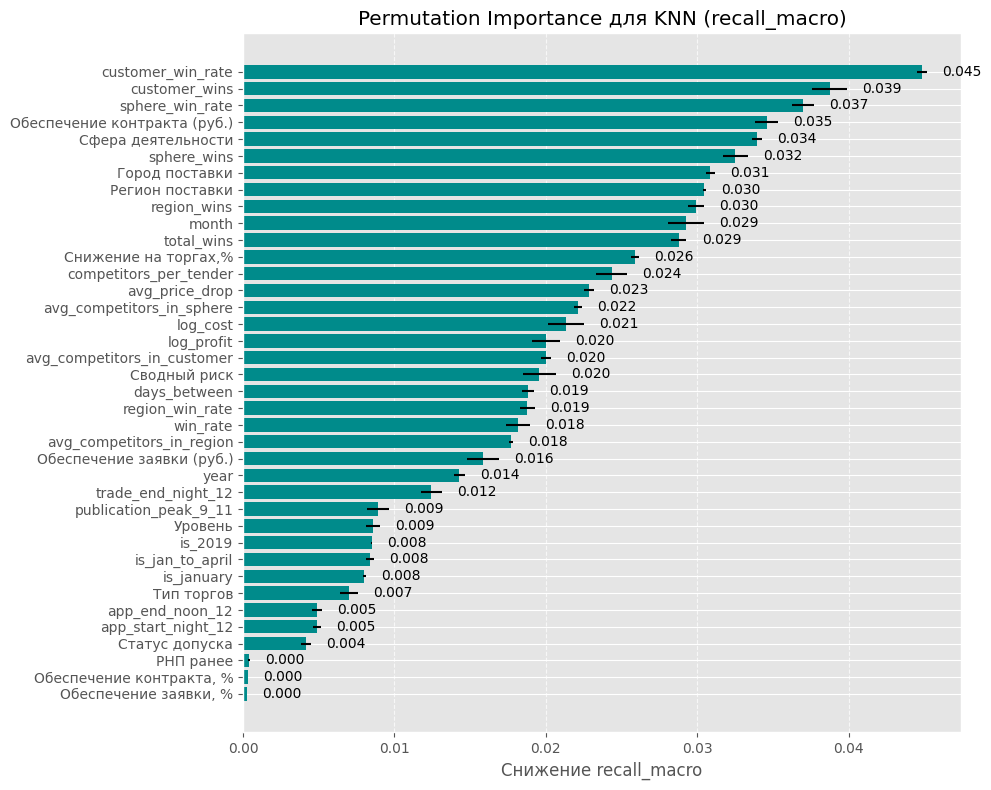

In [48]:
feature_names = X_val.columns

for metric, result in result.items():
    sorted_idx = result['importances_mean'].argsort()[::-1]

    print(f"Feature Importance Ranking for {metric}:")
    for i in sorted_idx:
        print(f"{feature_names[i]}: {result['importances_mean'][i]:.4f} ± {result['importances_std'][i]:.4f}")

    feat_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': result['importances_mean'],
        'importance_std': result['importances_std']
    })
    feat_df = feat_df.sort_values('importance_mean', ascending=True)

    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.barh(
        feat_df['feature'],
        feat_df['importance_mean'],
        xerr=feat_df['importance_std'],
        align='center',
        color='darkcyan'
    )
    ax.set_xlabel(f'Снижение {metric}')
    ax.set_title(f'Permutation Importance для KNN ({metric})')
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    for i, (mean, std) in enumerate(zip(feat_df['importance_mean'], feat_df['importance_std'])):
        ax.text(mean + std + 0.001, i, f"{mean:.3f}", va='center')

    plt.tight_layout()
    plt.show()

In [73]:
result = {
    'roc_auc': {
        'importances_mean': np.array([0.0169, 0.0139, 0.0135, 0.0117, 0.0107, 0.0103, 0.0102, 0.0101, 0.0100, 0.0099, 0.0099, 0.0091, 0.0091, 0.0081, 0.0081, 0.0080, 0.0079, 0.0079, 0.0077, 0.0073, 0.0071, 0.0070, 0.0068, 0.0051, 0.0048, 0.0040, 0.0038, 0.0036, 0.0035, 0.0035, 0.0035, 0.0032, 0.0021, 0.0019, 0.0013, 0.0002, -0.0000, -0.0001]),
        'importances_std': np.array([0.0001,  0.0002,  0.0003, 0.0000, 0.0000, 0.0000, 0.0001,  0.0002, 0.0004, 0.0000, 0.0003, 0.0001, 0.0001, 0.0002, 0.0001, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0001, 0.0000, 0.0001, 0.0001, 0.0001, 0.0004, 0.0001, 0.0004, 0.0002, 0.0000, 0.0002, 0.0002, 0.0001, 0.0000, 0.0001, 0.0000, 0.0000])
    },
    'f1_weighted': {
        'importances_mean': np.array([0.0418, 0.0351, 0.0344, 0.0319, 0.0311, 0.0290, 0.0284, 0.0280, 0.0268, 0.0267, 0.0262, 0.0237, 0.0225, 0.0207, 0.0201, 0.0194, 0.0182, 0.0181, 0.0177, 0.0172, 0.0171, 0.0165, 0.0161, 0.0150, 0.0131, 0.0113, 0.0082, 0.0081, 0.0079, 0.0078, 0.0074, 0.0065, 0.0046, 0.0046, 0.0039, 0.0005, 0.0004, 0.0003]),
        'importances_std': np.array([0.0004, 0.0006, 0.0010, 0.0007, 
                                     0.0004, 0.0009, 0.0002, 0.0001, 
                                     0.0005, 0.0011, 0.0005, 0.0004, 
                                     0.0010, 0.0003, 0.0002, 0.0011,
                                     0.0010, 0.0003, 0.0011, 0.0005, 
                                     0.0004, 0.0009, 0.0001, 0.0011, 
                                     0.0003, 0.0006, 0.0007, 0.0004, 
                                     0.0001, 0.0003, 0.0001, 0.0005,
                                     0.0004, 0.0003, 0.0003, 0.0000,
                                     0.0000, 0.000])
    },
    'precision_macro': {
        'importances_mean': np.array([0.0403, 0.0347, 0.0308, 0.0308,
                                      0.0297, 0.0273, 0.0269, 0.0267,
                                      0.0257, 0.025, 0.025, 0.0228,
                                      0.0219, 0.0199, 0.0193, 0.0187, 
                                      0.0177, 0.0175, 0.0171, 0.0168,
                                      0.0165, 0.0161,  0.0156,  0.0149,
                                      0.0129, 0.0111, 0.0082, 0.0081,
                                      0.0079, 0.0078, 0.0074, 0.0065,
                                      0.0046, 0.0046, 0.0040, 0.0005,
                                      0.0005, 0.0004]),
        'importances_std': np.array([0.0004, 0.0004, 0.0008, 0.0006,
                                     0.0004, 0.0002, 0.0001, 0.0010,
                                     0.0011, 0.0004, 0.0005, 0.0004,
                                     0.0010, 0.0003, 0.0002, 0.0010,
                                     0.0010, 0.0003, 0.0011, 0.0004,
                                     0.0004, 0.0010, 0.0001, 0.0011,
                                     0.0003, 0.0006, 0.0003, 0.0007,
                                     0.0001,0.0003, 0.0001, 0.0005, 
                                     0.0003,  0.0004, 0.0003, 0.0000, 
                                     0.0000, 0.0000])
    },
    'recall_macro': {
        'importances_mean':np.array([ 0.0448, 0.0387, 0.0370, 0.0346,
                                      0.0339, 0.0325, 0.0309, 0.0305, 
                                      0.0299, 0.0292, 0.0288, 0.0259, 
                                      0.0244, 0.0229, 0.0221, 0.0213, 
                                      0.0200, 0.0200,0.0196, 0.0188, 
                                      0.0188, 0.0182,
                                      0.0177, 0.0158, 0.0143, 0.0124, 
                                      0.0089, 0.0086, 0.0085, 0.0084, 
                                      0.0080, 0.0070, 0.0049, 0.0049, 
                                      0.0042, 0.0004, 0.0003, 0.0002]),
        'importances_std':np.array([0.0003, 0.0011, 0.0007, 0.0007, 
                                     0.0003, 0.0008, 0.0003, 0.0001, 
                                     0.0005, 0.0012, 0.0005, 0.0003, 
                                     0.0010, 0.0003, 0.0003, 0.0012, 
                                     0.0009, 0.0003, 0.0011, 0.0004,
                                     0.0008, 0.0001, 0.0011, 0.0004, 
                                     0.0007, 0.0007, 0.0004, 0.0000, 
                                     0.0003, 0.0001, 0.0006, 0.0003,
                                    0.0003,  0.0003,  0.0003, 0.0001,
                                    0.0000, 0.0000])
    }
}

In [75]:
feature_names = X_val.columns
for metric in ['roc_auc', 'f1_weighted', 'precision_macro', 'recall_macro']:
    feat_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': result[metric]['importances_mean'],
        'importance_std': result[metric]['importances_std']
    })
    feat_df = feat_df.sort_values('importance_mean', ascending=True)
    
    csv_filename = f"{metric}_importance_knn.csv"
    feat_df.to_csv(csv_filename, index=False)
    print(f"Saved {metric} importance to {csv_filename}")

Saved roc_auc importance to roc_auc_importance_knn.csv
Saved f1_weighted importance to f1_weighted_importance_knn.csv
Saved precision_macro importance to precision_macro_importance_knn.csv
Saved recall_macro importance to recall_macro_importance_knn.csv


In [81]:
metrics_to_save = {
    'model_name':'KNN',
    'Accuracy': 0.788,
    'Precision': 0.8766,
    'Recall': 0.8124,
    'F1-Score': 0.8433,
    'ROC-AUC': 0.8704,
    'Confusion Matrix': np.array([[11315,  4174], [ 6849, 29653]]),
     'tpr(for roc_curve)': tpr,
     'fpr(for roc_curve)': fpr,
     'thresholds(for roc_curve)': thresholds,
     'auc(for roc_curve)': roc_auc,
     'y_pred': y_pred,
     'y_proba': y_proba,
     'y_test': y_test,
     'confusion_matrix': confusion_matrix(y_test, y_pred)
}

In [82]:
metrics_to_save

{'model_name': 'KNN',
 'Accuracy': 0.788,
 'Precision': 0.8766,
 'Recall': 0.8124,
 'F1-Score': 0.8433,
 'ROC-AUC': 0.8704,
 'Confusion Matrix': array([[11315,  4174],
        [ 6849, 29653]]),
 'tpr(for roc_curve)': array([0.        , 0.17434661, 0.175689  , ..., 0.99991781, 1.        ,
        1.        ], shape=(14102,)),
 'fpr(for roc_curve)': array([0.        , 0.00103299, 0.00103299, ..., 0.99980631, 0.99980631,
        1.        ], shape=(14102,)),
 'thresholds(for roc_curve)': array([       inf, 1.        , 0.99442013, ..., 0.03045548, 0.01355681,
        0.01140098], shape=(14102,)),
 'auc(for roc_curve)': np.float64(0.870419099293873),
 'y_pred': array([1, 1, 1, ..., 1, 1, 0], shape=(51991,)),
 'y_proba': array([1.        , 0.98793593, 0.98858145, ..., 0.50208861, 0.55557192,
        0.44422664], shape=(51991,)),
 'y_test': 382139    1
 382140    1
 382143    1
 382145    1
 382146    1
          ..
 492015    0
 492017    0
 492018    0
 492019    0
 492020    0
 Name: Побед

In [83]:
metrics_to_save['Confusion Matrix'] = str(metrics_to_save['Confusion Matrix'])
metrics_to_save['tpr(for roc_curve)'] = str(metrics_to_save['tpr(for roc_curve)'])
metrics_to_save['fpr(for roc_curve)'] = str(metrics_to_save['fpr(for roc_curve)'])
metrics_to_save['thresholds(for roc_curve)'] = str(metrics_to_save['thresholds(for roc_curve)'])
metrics_to_save['y_pred'] = str(metrics_to_save['y_pred'])
metrics_to_save['y_proba'] = str(metrics_to_save['y_proba'])
metrics_to_save['y_test'] = str(metrics_to_save['y_test'].tolist())  

df = pd.DataFrame([metrics_to_save])
df.to_csv('knn_model_results.csv', index=False)

In [84]:
df

,model_name,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Confusion Matrix,tpr(for roc_curve),fpr(for roc_curve),thresholds(for roc_curve),auc(for roc_curve),y_pred,y_proba,y_test,confusion_matrix
0,KNN,0.79,0.88,0.81,0.84,0.87,[[11315 4174]\n [ 6849 29653]],[0. 0.17434661 0.175689 ... 0.999917...,[0. 0.00103299 0.00103299 ... 0.999806...,[ inf 1. 0.99442013 ... 0.030455...,0.87,[1 1 1 ... 1 1 0],[1. 0.98793593 0.98858145 ... 0.502088...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[11315, 4174], [6849, 29653]]"


In [15]:
import os
import copy
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
import numpy as np
import pandas as pd
from typing import Any, Dict, Optional, Tuple
from tqdm.auto import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class TenderDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        if isinstance(X, pd.DataFrame):
            X = X.values
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


class TenderNet(nn.Module):
    def __init__(self, input_size: int, hidden_size1: int = 100, hidden_size2: int = 50, dropout_rate: float = 0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_size1),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size1, hidden_size2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_size2),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size2, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

'''
def create_weighted_sampler(y: np.ndarray) -> WeightedRandomSampler:
    if isinstance(y, torch.Tensor):
        y = y.cpu().numpy()
    class_counts = np.bincount(y.astype(int))
    if len(class_counts) < 2 or class_counts.min() == 0:
        class_weights = torch.ones(len(np.unique(y)), dtype=torch.float)
    else:
        class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
    sample_weights = class_weights[y.astype(int)]
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
'''

def create_weighted_sampler(y, class_1_boost = 1.0):
    if isinstance(y, torch.Tensor):
        y = y.cpu().numpy()

    unique_classes = np.unique(y.astype(int))
    if not np.all(np.isin(unique_classes, [0, 1])):
        class_counts = np.bincount(y.astype(int))
        if len(class_counts) < 2 or class_counts.min() == 0:
            class_weights = torch.ones(len(unique_classes), dtype=torch.float)
        else:
            class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)

    else:
        class_counts = np.bincount(y.astype(int), minlength=2) 
        if class_counts[0] == 0 or class_counts[1] == 0:
            print("Warning: Only one class present in the provided labels. Applying uniform weight.")
            class_weights = torch.ones(2, dtype=torch.float)
        else:
            class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
            class_weights[1] *= class_1_boost

    sample_weights = class_weights[y.astype(int)]
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)


In [16]:
def train_model(
    model_params: Dict[str, Any],
    train_params: Dict[str, Any],
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    preprocessor: ColumnTransformer,
    n_epochs: int = 100,
    patience: int = 10,
    use_sampler: bool = True,
    device: torch.device = torch.device("cpu"),
    checkpoint_path: Optional[str] = None
) -> Tuple[nn.Module, float]:
    preprocessor.fit(X_train)
    X_train_proc = preprocessor.transform(X_train)
    X_val_proc = preprocessor.transform(X_val)

    input_size = X_train_proc.shape[1]
    model_params['input_size'] = input_size


    y_train_np = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
    y_val_np = y_val.values if hasattr(y_val, 'values') else np.array(y_val)
    train_ds = TenderDataset(X_train_proc, y_train_np)
    val_ds = TenderDataset(X_val_proc, y_val_np)

    sampler = create_weighted_sampler(y_train_np, class_1_boost=1.5) if use_sampler else None
    shuffle = not use_sampler

    train_loader = DataLoader(train_ds, batch_size=train_params.get('batch_size', 64),
                              sampler=sampler, shuffle=shuffle,
                              pin_memory=(device.type == 'cuda'))
    val_loader = DataLoader(val_ds, batch_size=train_params.get('batch_size', 64) * 2,
                            shuffle=False, pin_memory=(device.type == 'cuda'))

 
    model = TenderNet(**model_params).to(device)
    criterion = nn.BCEWithLogitsLoss()
    lr = train_params.get('learning_rate', 1e-3)
    optim_name = train_params.get('optimizer', 'Adam').lower()
    optimizer = optim.Adam(model.parameters(), lr=lr) if optim_name == 'adam' else optim.RMSprop(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=patience//2, factor=0.1)

    best_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in tqdm(range(n_epochs), desc="Training"):  
        model.train()
        running_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item() * Xb.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)


        if val_loss < best_loss:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            if checkpoint_path:
                os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
                torch.save({
                    'model_state_dict': best_state,
                    'preprocessor': preprocessor,
                    'input_size': input_size
                }, checkpoint_path)
                #print(f"Checkpoint saved at epoch {epoch+1} with val_loss={best_loss:.4f}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break


    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_loss



def predict_proba(
    model: nn.Module,
    X: pd.DataFrame,
    preprocessor: ColumnTransformer,
    device: torch.device,
    batch_size: int = 256
) -> np.ndarray:
    X_proc = preprocessor.transform(X)
    data = torch.tensor(X_proc, dtype=torch.float32)
    loader = DataLoader(data, batch_size=batch_size, shuffle=False)
    model.eval()
    probs = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.vstack(probs).squeeze()


In [30]:
preprocessor = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), num),
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat),
            ('pass', 'passthrough', binary_features)
        ], remainder='drop'
)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42, test_size=0.3, stratify=y_train)

model, loss = train_model(
        model_params={'hidden_size1': 512, 'hidden_size2': 32, 'dropout_rate': 0.4},
        train_params={'learning_rate': 0.00015639142257388656, 'batch_size': 256, 'optimizer': 'AdamW'},
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        preprocessor=preprocessor,
        n_epochs=50, patience=10,
        use_sampler=True,
        device=device,
        checkpoint_path='models_joblib/tender_mlp_model_and_preprocessor.pth'
)



Training: 100%|██████████| 50/50 [05:31<00:00,  6.64s/it]



MLP Metrics:
Accuracy: 0.8164
Precision: 0.8588
Recall: 0.8838
F1-Score: 0.8711
ROC-AUC: 0.9011

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.66      0.68     15489
           1       0.86      0.88      0.87     36502

    accuracy                           0.82     51991
   macro avg       0.78      0.77      0.78     51991
weighted avg       0.81      0.82      0.81     51991

Confusion Matrix:
[[10184  5305]
 [ 4243 32259]]


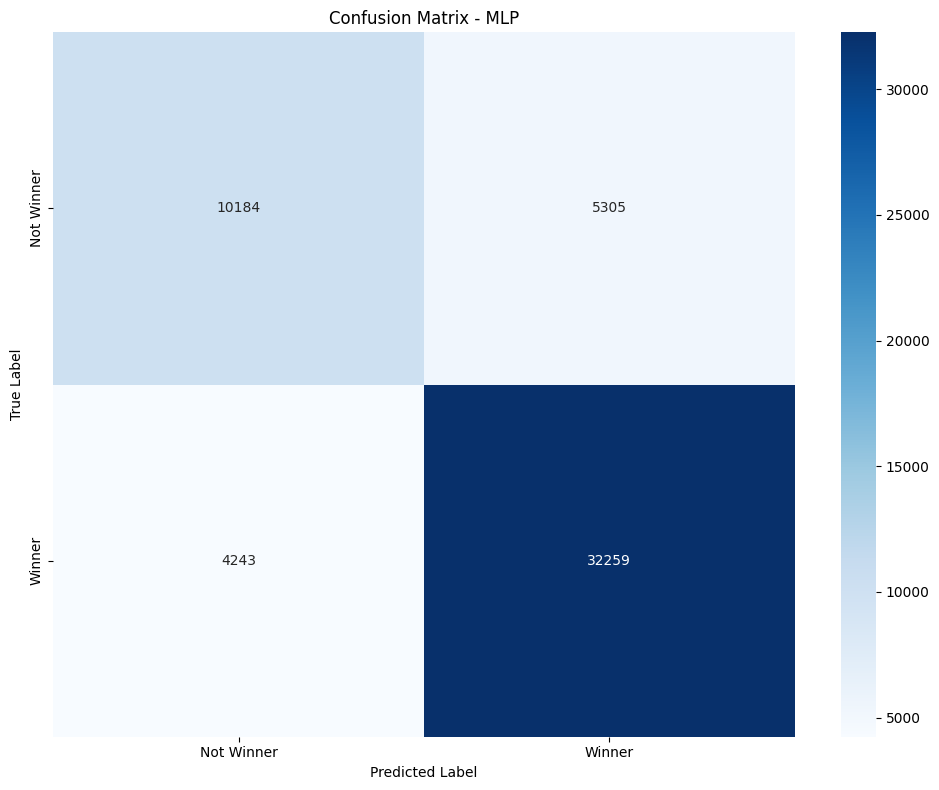

In [31]:
y_proba = predict_proba(model, X_test, preprocessor, device)
y_pred = (y_proba > 0.5).astype(int)
evaluate_model("MLP", y_test, y_pred, y_proba)

In [32]:
import optuna

def objective_mlp(trial):

    hidden_size1 = trial.suggest_categorical('hidden_size1', [64, 128, 256, 512])
    hidden_size2 = trial.suggest_categorical('hidden_size2', [32, 64, 128, 256])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)

    model_params = {
        'hidden_size1': hidden_size1,
        'hidden_size2': hidden_size2,
        'dropout_rate': dropout_rate
    }

    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop']) 
    patience = trial.suggest_categorical('patience', [5, 10, 20])
    train_params = {
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'optimizer': optimizer_name
    }
    model, best_val_loss = train_model(
            model_params=model_params,
            train_params=train_params,
            X_train=X_train, y_train=y_train, 
            X_val=X_val, y_val=y_val,        
            preprocessor=preprocessor,
            n_epochs=50,     
            patience=patience,    
            use_sampler=True, 
            device=device,
            checkpoint_path=None 
    )
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    return best_val_loss
    
study_mlp = optuna.create_study(direction='minimize')
n_trials_mlp = 50 
study_mlp.optimize(objective_mlp, n_trials=n_trials_mlp)

[I 2025-04-28 21:53:17,047] A new study created in memory with name: no-name-faab42cd-6de0-40e8-8acd-94a7ccdc4a0e
Training:  26%|██▌       | 13/50 [00:24<01:08,  1.85s/it]
[I 2025-04-28 21:53:42,002] Trial 0 finished with value: 0.19469107650753095 and parameters: {'hidden_size1': 512, 'hidden_size2': 32, 'dropout_rate': 0.2, 'learning_rate': 0.00266512698303402, 'batch_size': 64, 'optimizer': 'Adam', 'patience': 10}. Best is trial 0 with value: 0.19469107650753095.


Early stopping at epoch 14


Training:  70%|███████   | 35/50 [00:30<00:13,  1.15it/s]
[I 2025-04-28 21:54:13,448] Trial 1 finished with value: 0.17612279707770967 and parameters: {'hidden_size1': 256, 'hidden_size2': 32, 'dropout_rate': 0.5, 'learning_rate': 0.0003873199463361111, 'batch_size': 64, 'optimizer': 'AdamW', 'patience': 5}. Best is trial 1 with value: 0.17612279707770967.


Early stopping at epoch 36


Training: 100%|██████████| 50/50 [00:34<00:00,  1.45it/s]
[I 2025-04-28 21:54:48,906] Trial 2 finished with value: 0.17502596232624795 and parameters: {'hidden_size1': 512, 'hidden_size2': 128, 'dropout_rate': 0.5, 'learning_rate': 6.587802001768335e-05, 'batch_size': 256, 'optimizer': 'AdamW', 'patience': 20}. Best is trial 2 with value: 0.17502596232624795.
Training:  40%|████      | 20/50 [00:17<00:25,  1.16it/s]
[I 2025-04-28 21:55:06,850] Trial 3 finished with value: 0.18705172786406637 and parameters: {'hidden_size1': 256, 'hidden_size2': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0006888282684871562, 'batch_size': 64, 'optimizer': 'AdamW', 'patience': 10}. Best is trial 2 with value: 0.17502596232624795.


...

Early stopping at epoch 21


Training: 100%|██████████| 50/50 [00:40<00:00,  1.22it/s]
[I 2025-04-28 22:17:50,593] Trial 44 finished with value: 0.17645152773866882 and parameters: {'hidden_size1': 512, 'hidden_size2': 32, 'dropout_rate': 0.4, 'learning_rate': 7.181236751907463e-05, 'batch_size': 256, 'optimizer': 'AdamW', 'patience': 10}. Best is trial 40 with value: 0.16523878355374125.
Training:  60%|██████    | 30/50 [00:25<00:17,  1.17it/s]
[I 2025-04-28 22:18:17,038] Trial 45 finished with value: 0.1811635537287907 and parameters: {'hidden_size1': 512, 'hidden_size2': 256, 'dropout_rate': 0.1, 'learning_rate': 0.0002510910465423614, 'batch_size': 256, 'optimizer': 'AdamW', 'patience': 10}. Best is trial 40 with value: 0.16523878355374125.


Early stopping at epoch 31


Training: 100%|██████████| 50/50 [00:23<00:00,  2.15it/s]
[I 2025-04-28 22:18:41,050] Trial 46 finished with value: 0.17226038736399968 and parameters: {'hidden_size1': 256, 'hidden_size2': 32, 'dropout_rate': 0.5, 'learning_rate': 0.00032149742834716065, 'batch_size': 256, 'optimizer': 'RMSprop', 'patience': 10}. Best is trial 40 with value: 0.16523878355374125.
Training: 100%|██████████| 50/50 [00:39<00:00,  1.26it/s]
[I 2025-04-28 22:19:21,471] Trial 47 finished with value: 0.17451924234980365 and parameters: {'hidden_size1': 512, 'hidden_size2': 32, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.00011750702148716189, 'batch_size': 256, 'optimizer': 'AdamW', 'patience': 10}. Best is trial 40 with value: 0.16523878355374125.
Training: 100%|██████████| 50/50 [00:22<00:00,  2.26it/s]
[I 2025-04-28 22:19:44,376] Trial 48 finished with value: 0.17486559158892132 and parameters: {'hidden_size1': 128, 'hidden_size2': 32, 'dropout_rate': 0.4, 'learning_rate': 7.770878926177354e-05,

Early stopping at epoch 28


In [33]:
print(f"Best trial number: {study_mlp.best_trial.number}")
print(f"Best Validation Loss: {study_mlp.best_value}") 
print("Best hyperparameters found:")

best_model_params = {}
best_train_params = {}
for key, value in study_mlp.best_params.items():
    print(f"  {key}: {value}")
    if key in ['hidden_size1', 'hidden_size2', 'dropout_rate']:
        best_model_params[key] = value
    elif key in ['learning_rate', 'batch_size', 'optimizer']:
         best_train_params[key] = value

Best trial number: 40
Best Validation Loss: 0.16523878355374125
Best hyperparameters found:
  hidden_size1: 512
  hidden_size2: 32
  dropout_rate: 0.4
  learning_rate: 0.00015639142257388656
  batch_size: 256
  optimizer: AdamW
  patience: 10
